# Color Scheme (experimental)

In [1]:
import yfinance as yf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume
from mplchart.indicators import SMA, EMA, WMA, HMA, ROC, RSI, MACD, DMI
from mplchart.utils import normalize_prices

In [2]:
ticker = "AAPL"
prices = normalize_prices(yf.Ticker(ticker).history(period="5y"))
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-07-19 00:00:00-04:00 to 2026-07-17 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          1255 non-null   float64
 1   high          1255 non-null   float64
 2   low           1255 non-null   float64
 3   close         1255 non-null   float64
 4   volume        1255 non-null   int64  
 5   dividends     1255 non-null   float64
 6   stock splits  1255 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


pdi #2ca02c
ndi #d62728
sma #d62728
sma #2ca02c
sma #1f77b4


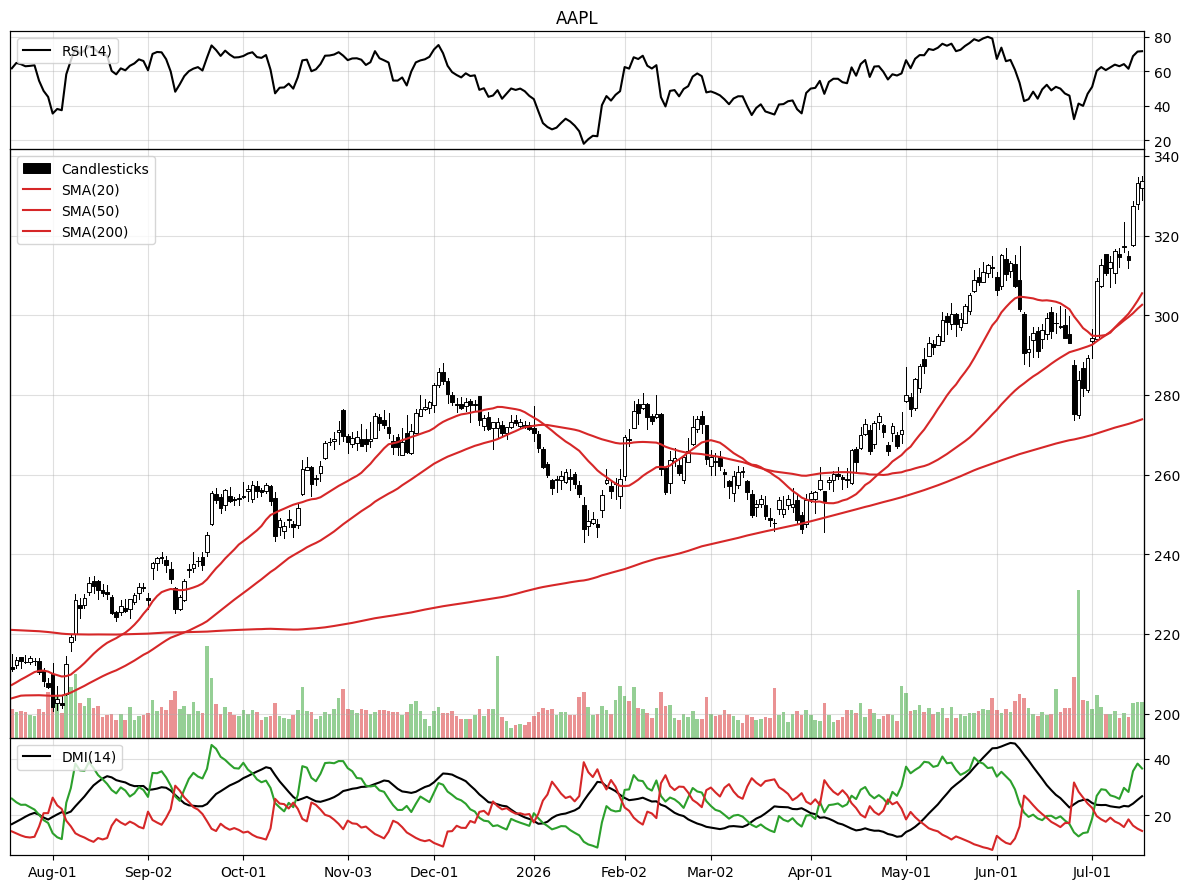

In [3]:
color_scheme = dict(pdi="~green", ndi="~red", sma=["~r", "~g", "~b"])

max_bars = 250

indicators = [
    Candlesticks(),
    SMA(20),
    SMA(50),
    SMA(200),
    Volume(),
    RSI(),
    DMI(),
]

chart = Chart(prices, title=ticker, max_bars=max_bars, color_scheme=color_scheme)

for name in "pdi", "ndi", "sma", "sma", "sma":
    color = chart.canvas.get_color(name, None)
    print(name, color)


chart.plot(
    Candlesticks(),
    SMA(20),
    SMA(50),
    SMA(200),
    Volume(),
).pane("above").plot(
    RSI(),
).pane("below").plot(
    DMI(),
)